In [1]:
# input
ATAC_folder = '/data/input/Files/User/huangpeilin/HuBeiNongKeYuan_rice_embryo/ATAC/ZHL-8d-1229-DNA/ZHL-8d-1229-DNA/output'
ATAC_metadata = file.path(ATAC_folder, "singlecell.csv")
ATAC_fragments = file.path(ATAC_folder, "fragments.tsv.gz")
gtf_path = '/data/input/Files/User/yinzhanhao/index/rice/osa1_r7.all_models.gtf'
cluster_key = 'dataset'
marker_list = 'LOC-Os01g01010,LOC-Os01g01019,LOC-Os01g01030,LOC-Os01g01040'
split_signal_value = 0.3
min_nCount_peaks = 1000
max_nCount_peaks = 100000
min_pct_reads_in_peaks = 40
max_nucleosome_signal = 4
min_TSS_enrichment = 1

# Signac https://stuartlab.org/signac/articles/pbmc_vignette

In [2]:
suppressMessages({
  library(Signac)
  library(Seurat)
  library(GenomicRanges)
  library(ggplot2)
  library(patchwork)
  library(AnnotationDbi)
  library(rtracklayer)
})

In [3]:
# counts <- Read10X_h5(filename = "10k_pbmc_ATACv2_nextgem_Chromium_Controller_filtered_peak_bc_matrix.h5")

counts <- Matrix::readMM(file.path(ATAC_folder, "filter_peak_matrix", "matrix.mtx.gz"))
barcodes <- readLines(file.path(ATAC_folder, "filter_peak_matrix", "barcodes.tsv.gz"))
peaks <- read.table(file.path(ATAC_folder, "filter_peak_matrix", "peaks.bed.gz"), sep = "\t")
peaknames <- paste(peaks$V1, peaks$V2, peaks$V3, sep = "-")

colnames(counts) <- barcodes
rownames(counts) <- peaknames

In [4]:
dim(counts)
str(counts)

[1] 60949  5692

Formal class 'dgTMatrix' [package "Matrix"] with 6 slots
  ..@ i       : int [1:12744472] 0 0 0 0 0 0 0 0 0 0 ...
  ..@ j       : int [1:12744472] 9 17 31 66 72 80 84 93 96 119 ...
  ..@ Dim     : int [1:2] 60949 5692
  ..@ Dimnames:List of 2
  .. ..$ : chr [1:60949] "Chr1-1009-1361" "Chr1-1581-2095" "Chr1-2469-3228" "Chr1-3419-3698" ...
  .. ..$ : chr [1:5692] "CELL4_N4" "CELL5_N2" "CELL7_N4" "CELL10_N3" ...
  ..@ x       : num [1:12744472] 1 1 1 2 1 1 2 1 1 1 ...
  ..@ factors : list()


In [5]:
metadata <- read.csv(
  file = ATAC_metadata,
  header = TRUE,
  row.names = 1
)

chrom_assay <- CreateChromatinAssay(
  counts = counts,
  sep = c("-", "-"),
  fragments = ATAC_fragments,
  min.cells = 10,
  min.features = 200
)

pbmc <- CreateSeuratObject(
  counts = chrom_assay,
  assay = "peaks",
  meta.data = metadata
)

Computing hash



In [6]:
pbmc; colnames(pbmc@meta.data)

An object of class Seurat 
60949 features across 5692 samples within 1 assay 
Active assay: peaks (60949 features, 0 variable features)
 2 layers present: counts, data

[1] "orig.ident"            "nCount_peaks"          "nFeature_peaks"       
 [4] "totalFrags"            "fragments"             "mt_region_fragments"  
 [7] "TSS_region_fragments"  "peaks_number"          "peak_region_fragments"
[10] "is_cell_barcode"       "Cellbarcode"

In [7]:
pbmc[['peaks']]@counts[1:5,1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
                 CELL4_N4 CELL5_N2 CELL7_N4 CELL10_N3 CELL11_N3
Chr1-1009-1361          .        .        .         .         .
Chr1-1581-2095          .        .        .         .         .
Chr1-2469-3228          .        .        .         .         .
Chr1-3419-3698          .        .        .         .         .
Chr1-16300-16487        .        .        .         .         .

In [8]:
granges(pbmc)

GRanges object with 60949 ranges and 0 metadata columns:
          seqnames            ranges strand
             <Rle>         <IRanges>  <Rle>
      [1]     Chr1         1009-1361      *
      [2]     Chr1         1581-2095      *
      [3]     Chr1         2469-3228      *
      [4]     Chr1         3419-3698      *
      [5]     Chr1       16300-16487      *
      ...      ...               ...    ...
  [60945]     Chr9 22917366-22917691      *
  [60946]     Chr9 22917895-22918288      *
  [60947]     Chr9 22931134-22931284      *
  [60948]     Chr9 22934594-22934834      *
  [60949]     Chr9 22938488-22938750      *
  -------
  seqinfo: 12 sequences from an unspecified genome; no seqlengths

## Remove unneeded scaffold info and add gene annotation

In [9]:
# peaks.keep <- seqnames(granges(pbmc)) %in% standardChromosomes(granges(pbmc))
# pbmc <- pbmc[as.vector(peaks.keep), ]

In [10]:
# library(AnnotationHub)
# ah <- AnnotationHub()

# # Search for the Ensembl 98 EnsDb for Homo sapiens on AnnotationHub
# query(ah, "EnsDb.Hsapiens.v98")

# ensdb_v98 <- ah[["AH75011"]]

# # extract gene annotations from EnsDb
# annotations <- GetGRangesFromEnsDb(ensdb = ensdb_v98)

# # change to UCSC style since the data was mapped to hg38
# seqlevels(annotations) <- paste0('chr', seqlevels(annotations))
# genome(annotations) <- "hg38"

# # add the gene information to the object
# Annotation(pbmc) <- annotations

## Add genes annotation

In [11]:
# 1. 导入 GTF
gtf <- rtracklayer::import(gtf_path)

# # 2. 只保留转录本（因为 Signac 主要用转录本信息）
# tx_only <- gtf[gtf$type == "transcript"]
tx_only <- gtf

# 3. 添加缺失的字段
mcols(tx_only)$gene_name <- tx_only$gene_id
mcols(tx_only)$gene_biotype <- "protein_coding"
# mcols(tx_only)$type <- "transcript"

# 4. 重命名转录本ID列
if("transcript_id" %in% names(mcols(tx_only))) {
  mcols(tx_only)$tx_id <- tx_only$transcript_id
}

# 5. 添加到 Seurat 对象
Annotation(pbmc) <- tx_only

In [12]:
print(Annotation(pbmc)[1:5])

GRanges object with 5 ranges and 9 metadata columns:
      seqnames     ranges strand |     source       type     score     phase
         <Rle>  <IRanges>  <Rle> |   <factor>   <factor> <numeric> <integer>
  [1]     Chr1 2903-10817      + | MSU_osa1r7 transcript        NA      <NA>
  [2]     Chr1  2903-3268      + | MSU_osa1r7 exon              NA      <NA>
  [3]     Chr1  3354-3616      + | MSU_osa1r7 exon              NA      <NA>
  [4]     Chr1  4357-4455      + | MSU_osa1r7 exon              NA      <NA>
  [5]     Chr1  5457-5560      + | MSU_osa1r7 exon              NA      <NA>
         transcript_id        gene_id      gene_name   gene_biotype
           <character>    <character>    <character>    <character>
  [1] LOC_Os01g01010.1 LOC_Os01g01010 LOC_Os01g01010 protein_coding
  [2] LOC_Os01g01010.1 LOC_Os01g01010 LOC_Os01g01010 protein_coding
  [3] LOC_Os01g01010.1 LOC_Os01g01010 LOC_Os01g01010 protein_coding
  [4] LOC_Os01g01010.1 LOC_Os01g01010 LOC_Os01g01010 protein_coding


## Computing QC Metrics https://stuartlab.org/signac/articles/pbmc_vignette#computing-qc-metrics
1. nucleosome banding pattern
2. transcriptional start site (TSS) enrichment score
3. total number of fragments in peaks
4. fraction of fragments in peaks
5. ratio reads in genomic blacklist regions

In [13]:
# compute nucleosome signal score per cell
pbmc <- NucleosomeSignal(object = pbmc)

# compute TSS enrichment score per cell
# pbmc <- TSSEnrichment(object = pbmc) # default fast=TRUE
pbmc <- TSSEnrichment(object = pbmc, fast=FALSE) # If you next run TSSPlot(), please set fast=FALSE

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score



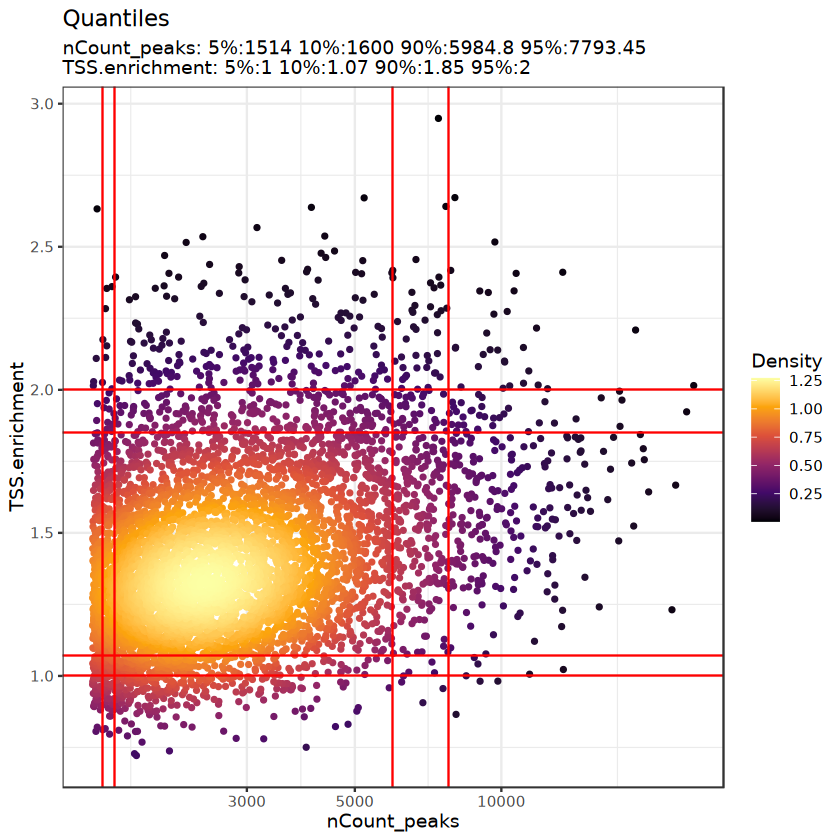

In [14]:
DensityScatter(pbmc, x = 'nCount_peaks', y = 'TSS.enrichment', log_x = TRUE, quantiles = TRUE)

In [17]:
pbmc

An object of class Seurat 
60949 features across 5692 samples within 1 assay 
Active assay: peaks (60949 features, 0 variable features)
 2 layers present: counts, data

In [19]:
pbmc <- TSSEnrichment(object = pbmc, fast=FALSE)

Extracting TSS positions

Finding + strand cut sites

Finding - strand cut sites

Computing mean insertion frequency in flanking regions

Normalizing TSS score



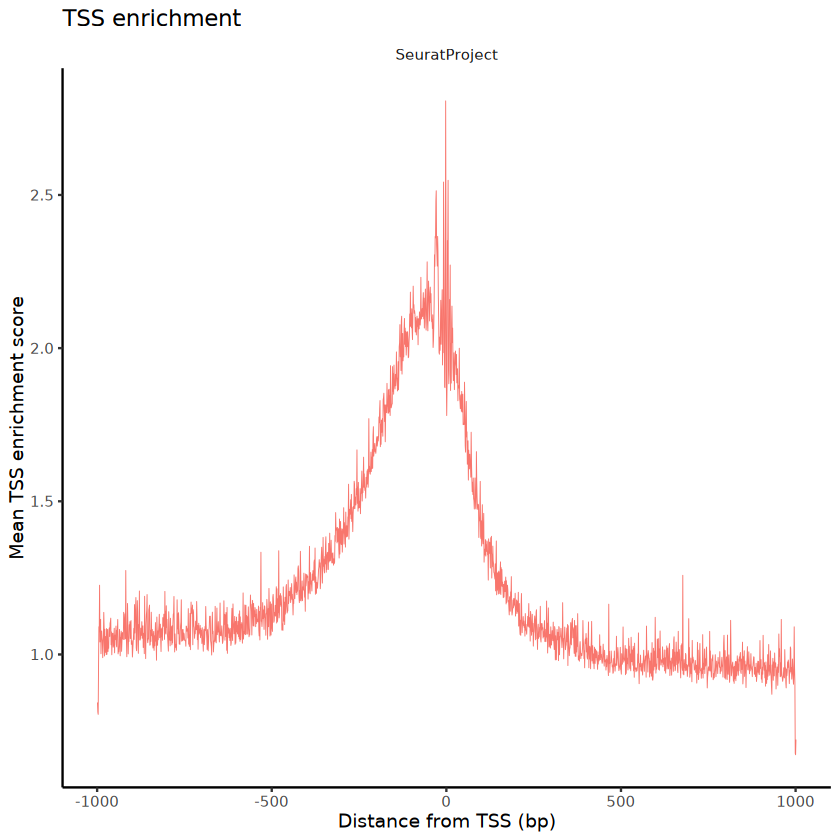

In [20]:
TSSPlot(pbmc, assay = "peaks", group.by = NULL, idents = NULL)

In [15]:
# # add fraction of reads in peaks
# pbmc$pct_reads_in_peaks <- pbmc$peak_region_fragments / pbmc$passed_filters * 100

# # add blacklist ratio
# pbmc$blacklist_ratio <- FractionCountsInRegion(
#   object = pbmc, 
#   assay = 'peaks',
#   regions = blacklist_hg38_unified
# )

# add fraction of reads in peaks
pbmc$pct_reads_in_peaks <- pbmc$peak_region_fragments / pbmc$fragments * 100

[1] "NS < 0.3" "NS > 0.3"

Warning message:
“Removed 447 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_bar()`).”


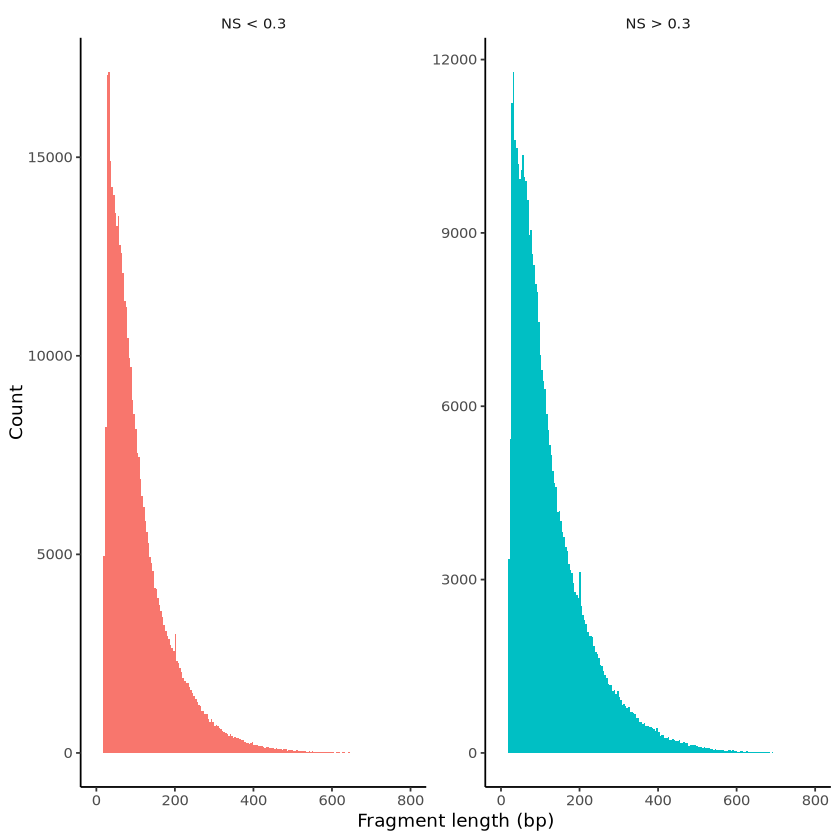

In [16]:
pbmc$nucleosome_group <- ifelse(pbmc$nucleosome_signal > split_signal_value, paste0("NS > ", split_signal_value), paste0("NS < ", split_signal_value))
unique(pbmc$nucleosome_group)
FragmentHistogram(object = pbmc, group.by = 'nucleosome_group', region = "Chr1-1-2000000") # 默认是对chr1-1-2000000区域进行片段长度分布的可视化

In [17]:
head(pbmc@meta.data)

,orig.ident,nCount_peaks,nFeature_peaks,totalFrags,fragments,mt_region_fragments,TSS_region_fragments,peaks_number,peak_region_fragments,is_cell_barcode,Cellbarcode,nucleosome_signal,nucleosome_percentile,TSS.enrichment,TSS.percentile,pct_reads_in_peaks,nucleosome_group
,<fct>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CELL1_N6,SeuratProject,6615,5194,16861,12613,0,4778,5194,6615,1,AACACCTGATAACCTTGCGG;CGCTGAATTCCTTGGTGGTT;CGTGAGCTCCTTCGTTGTGC;GTCAGGATCGCCTATTGGTG;TAACATAGCATTCGTCGCCA;TTGGTAAGTTCATAGCGACG,0.2686763,0.35,1.658533,0.77,52.44589,NS < 0.3
CELL3_N2,SeuratProject,5488,3840,16178,11460,0,3847,3840,5488,1,AACACCTGATACAGTCGGAT;TTGACATCTCGTGACCTAAC,0.2647929,0.32,1.357964,0.40,47.88831,NS < 0.3
CELL6_N2,SeuratProject,3811,2806,9832,6632,0,2253,2806,3811,1,AACACCTGATCAGAGTGCCA;AGCAACATGAAATCTACAAG,0.2095808,0.04,1.818371,0.90,57.46381,NS < 0.3
CELL9_N4,SeuratProject,4382,3186,9894,7411,0,2503,3186,4382,1,AACACCTGATGATGGAGTGC;ATACGGATTAATCTCAAGCC;GAAGAATGTGGCGGTACAAG;GTTGTATGCAGCTCAACTAA,0.2454175,0.20,1.442160,0.50,59.12832,NS < 0.3
CELL10_N6,SeuratProject,9030,5435,19301,13948,0,5134,5435,9030,1,AACACCTGATGTCGCCTTGA;AAGGTACATACAAGCTGAAG;ACTACCGTGCACAGAATGAA;AGTGTTGCTTAAGATGGCCT;GCGCGTACGCGCGGTGCAGA;TCAGTACACGCCGCAGGAGC,0.2592375,0.29,1.947344,0.95,64.74046,NS < 0.3
CELL11_N3,SeuratProject,2995,2225,15680,11648,0,3938,2225,2995,1,AACACCTGATTAGCTGCTAC;GAGATGCGTGGTGTGAAGTT;GTCAGGTCGTCAGATTCAAC,0.3029289,0.58,1.193109,0.20,25.71257,NS > 0.3


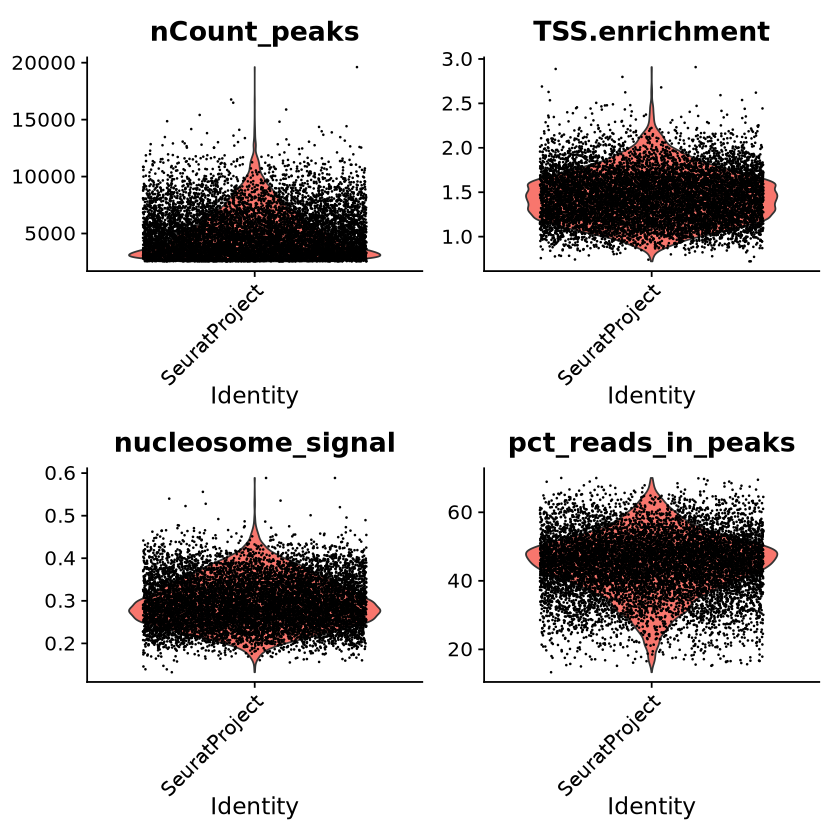

In [18]:
# violin plot of QC metrics
VlnPlot(object = pbmc, features = c("nCount_peaks", "TSS.enrichment", "nucleosome_signal", "pct_reads_in_peaks"), pt.size = 0.1, ncol = 2)

In [19]:
# filter out low_quality cells
pbmc <- subset(
    x = pbmc,
    subset = nCount_peaks > min_nCount_peaks &
                     nCount_peaks < max_nCount_peaks &
                     pct_reads_in_peaks > min_pct_reads_in_peaks &
                     nucleosome_signal < max_nucleosome_signal &
                     TSS.enrichment > min_TSS_enrichment
)

In [20]:
pbmc

An object of class Seurat 
65676 features across 7234 samples within 1 assay 
Active assay: peaks (65676 features, 0 variable features)
 2 layers present: counts, data

## normalization and linear dimensional reduction

In [21]:
# normalization: term frequency-inverse document frequency(TF-IDF)
pbmc <- RunTFIDF(pbmc)
# feature selection: remove features present in less than n cells with the `FindTopFeatures()`
pbmc <- FindTopFeatures(pbmc, min.cutoff = "q0")
# dimension reduction: singular value decomposition(SVD) on the TD-IDF matrix
pbmc <- RunSVD(pbmc)

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font width unknown for character 0x09 in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font width unknown for character 0x09 in encoding latin1”


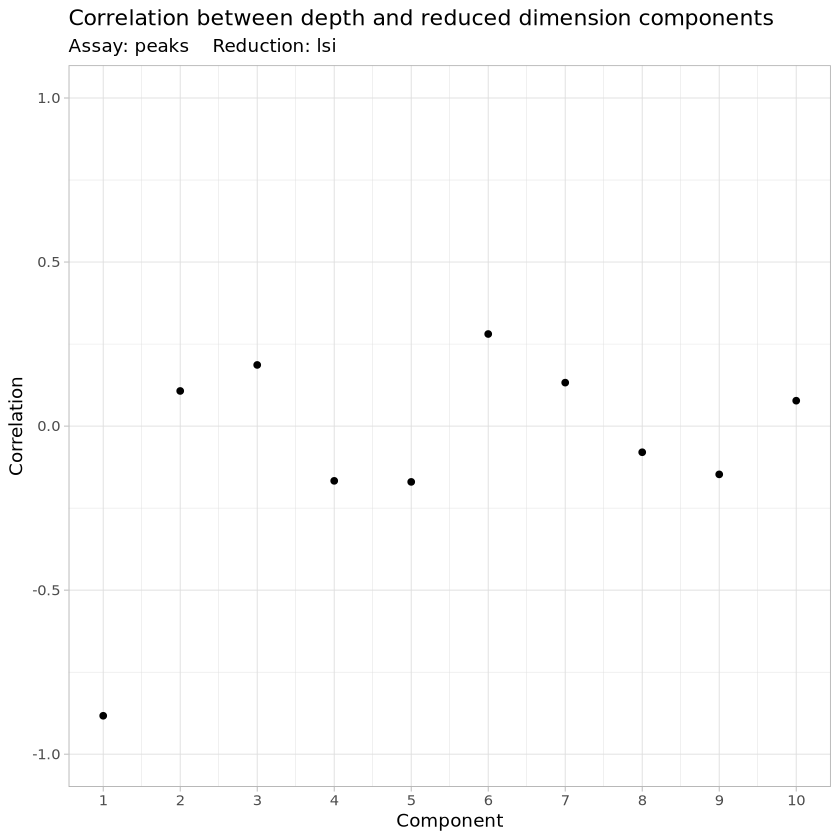

In [22]:
# assess the correlation between each LSI component and sequence depth
DepthCor(pbmc) # select LSI components that are not correlated with sequencing depth (e.g. 2-30)

## non-linear dimension reduction and clustering

In [23]:
pbmc <- RunUMAP(object = pbmc, reduction = 'lsi', dims = 2:30)
pbmc <- FindNeighbors(object = pbmc, reduction = 'lsi', dims = 2:30)
pbmc <- FindClusters(object = pbmc, verbose = FALSE, algorithm = 3)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
01:16:09 UMAP embedding parameters a = 0.9922 b = 1.112

01:16:09 Read 7234 rows and found 29 numeric columns

01:16:09 Using Annoy for neighbor search, n_neighbors = 30

01:16:09 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01:16:10 Writing NN index file to temp file /tmp/RtmpYRUYdS/file1497aa75a18

01:16:10 Searching Annoy index using 1 thread, search_k = 3000

01:16:12 Annoy recall = 100%

01:16:15 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

In [44]:
colnames(pbmc@meta.data)

[1] "orig.ident"            "nCount_peaks"          "nFeature_peaks"       
 [4] "totalFrags"            "fragments"             "mt_region_fragments"  
 [7] "TSS_region_fragments"  "peaks_number"          "peak_region_fragments"
[10] "is_cell_barcode"       "Cellbarcode"           "nucleosome_signal"    
[13] "nucleosome_percentile" "TSS.enrichment"        "TSS.percentile"       
[16] "pct_reads_in_peaks"    "nucleosome_group"      "peaks_snn_res.0.8"    
[19] "seurat_clusters"       "nCount_RNA"            "nFeature_RNA"

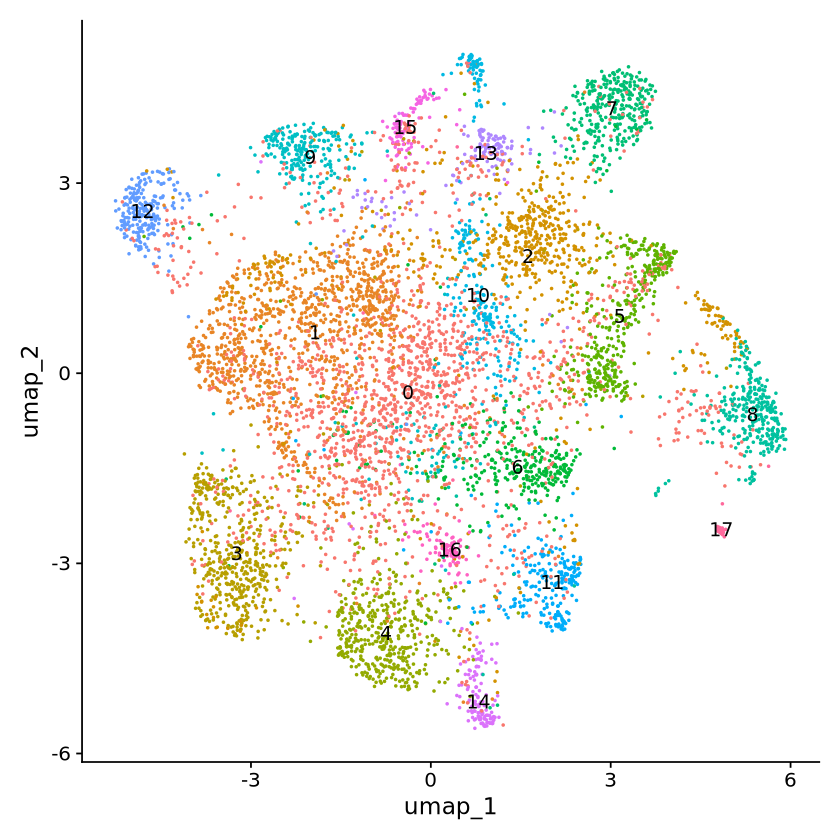

In [24]:
DimPlot(object = pbmc, label = TRUE) + NoLegend()

## create a gene activity matrix

In [25]:
gene.activities <- GeneActivity(pbmc)

Extracting gene coordinates

Warning message in SingleFeatureMatrix(fragment = fragments[[x]], features = features, :
“185 features are on seqnames not present in the fragment file. These will be removed.”
Extracting reads overlapping genomic regions



In [27]:
gene.activities[1:5, 1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
               CELL1_N6 CELL3_N2 CELL6_N2 CELL9_N4 CELL10_N6
LOC_Os01g01010        .        1        .        .         .
LOC_Os01g01019        .        1        .        .         .
LOC_Os01g01030        .        .        .        .         .
LOC_Os01g01040        .        .        .        .         1
LOC_Os01g01050        1        .        .        .         .

In [39]:
# add the gene activity matrix to the Seurat object as a new assay and normalize it
pbmc[['RNA']] <- CreateAssayObject(counts = gene.activities)
pbmc <- NormalizeData(
  object = pbmc,
  assay = 'RNA',
  normalization.method = 'LogNormalize',
  scale.factor = median(pbmc$nCount_RNA)
)

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


In [40]:
head(rownames(pbmc[['RNA']]))

[1] "LOC-Os01g01010" "LOC-Os01g01019" "LOC-Os01g01030" "LOC-Os01g01040"
[5] "LOC-Os01g01050" "LOC-Os01g01060"

In [41]:
pbmc

An object of class Seurat 
121477 features across 7234 samples within 2 assays 
Active assay: RNA (55801 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: peaks
 2 dimensional reductions calculated: lsi, umap

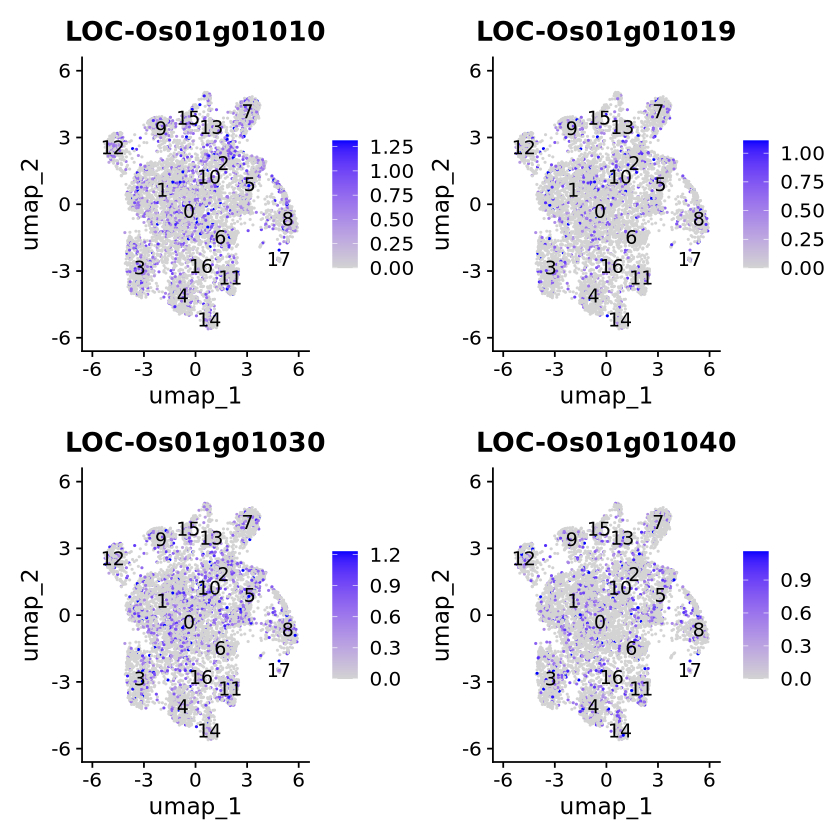

In [ ]:
DefaultAssay(pbmc) <- 'RNA'

FeaturePlot(
  object = pbmc,
  features = strsplit(marker_list, ",")[[1]],
  group.by = cluster_key,
  pt.size = 0.1,
  label = TRUE,
  max.cutoff = 'q95',
  ncol = 2
)

## Integrating with scRNA-seq data

In [ ]:
# gene activity matrix and scRNA-seq dataset to identify matched biological states across the two modalities

# Load the pre-processed scRNA-seq data for PBMCs
pbmc_rna <- readRDS("pbmc_10k_v3.rds")
pbmc_rna <- UpdateSeuratObject(pbmc_rna)

reduction: Dimensional reduction to perform when finding anchors. Options are:

- pcaproject: Project the PCA from the reference onto the query. We recommend using PCA when reference and query datasets are from scRNA-seq
- lsiproject: Project the LSI from the reference onto the query. We recommend using LSI when reference and query datasets are from scATAC-seq. This requires that LSI has been computed for the reference dataset, and the same features (eg, peaks or genome bins) are present in both the reference and query. See RunTFIDF and RunSVD
- rpca: Project the PCA from the reference onto the query, and the PCA from the query onto the reference (reciprocal PCA projection).
- cca: Run a CCA on the reference and query

In [ ]:
transfer.anchors <- FindTransferAnchors(
  reference = pbmc_rna,
  query = pbmc,
  reduction = 'cca'
)

In [ ]:
predicted.labels <- TransferData(
  anchorset = transfer.anchors,
  refdata = pbmc_rna$celltype,
  weight.reduction = pbmc[['lsi']],
  dims = 2:30
)

use annotations of rna to annotation cell types of atac 

In [ ]:
pbmc <- AddMetaData(object = pbmc, metadata = predicted.labels)

plot1 <- DimPlot(
  object = pbmc_rna,
  group.by = 'celltype',
  label = TRUE,
  repel = TRUE) + NoLegend() + ggtitle('scRNA-seq')

plot2 <- DimPlot(
  object = pbmc,
  group.by = 'predicted.id',
  label = TRUE,
  repel = TRUE) + NoLegend() + ggtitle('scATAC-seq')

plot1 + plot2

Plotting the prediction score for the cells assigned to each label reveals that the “platelet” cells received relatively low scores (< 0.8), indicating a low confidence in the assigned cell identity. 

In [ ]:
VlnPlot(pbmc, 'prediction.score.max', group.by = 'predicted.id')

In [ ]:
# Identify the metadata columns that start with "prediction.score."
metadata_attributes <- colnames(pbmc[[]])
prediction_score_attributes <- grep("^prediction.score.", metadata_attributes, value = TRUE)
prediction_score_attributes <- setdiff(prediction_score_attributes, "prediction.score.max")

# Extract the prediction score attributes for these cells
predicted_platelets <- which(pbmc$predicted.id == "Platelet")
platelet_scores <- pbmc[[]][predicted_platelets, prediction_score_attributes]

# Order the columns by their average values in descending order
ordered_columns <- names(sort(colMeans(platelet_scores, na.rm = TRUE), decreasing = TRUE))
ordered_platelet_scores_df <- platelet_scores[, ordered_columns]

print(ordered_platelet_scores_df)

因此，对于下游分析，我们将删除预测的极其罕见的细胞状态，只保留总共>20个细胞的细胞注释。

In [ ]:
predicted_id_counts <- table(pbmc$predicted.id)

# Identify the predicted.id values that have more than 20 cells
major_predicted_ids <- names(predicted_id_counts[predicted_id_counts > 20])
pbmc <- pbmc[, pbmc$predicted.id %in% major_predicted_ids]

In [ ]:
# change cell identities to the per-cell predicted labels
Idents(pbmc) <- pbmc$predicted.id

**To combine clustering and label transfer results**

In [ ]:
# replace each cluster label with its most likely predicted label
for(i in levels(pbmc)) {
  cells_to_reid <- WhichCells(pbmc, idents = i)
  newid <- names(which.max(table(pbmc$predicted.id[cells_to_reid])))
  Idents(pbmc, cells = cells_to_reid) <- newid
}

## Find differentially accessible peaks between cell types

In [ ]:
# if (!requireNamespace("remotes", quietly = TRUE))
#   install.packages('remotes')
# remotes::install_github('immunogenomics/presto')

In [ ]:
# change back to working with peaks instead of gene activities
DefaultAssay(pbmc) <- "peaks"

# wilcox is the default option for test.use
da_peaks <- FindMarkers(
    object = pbmc,
    ident.1 = "CD4 Naive",
    ident.2 = "CD14+ Monocytes",
    test.use = "wilcox",
    min.pct = 0.1
)

head(da_peaks)

<details> <summary> Logistic regression with total fragment number as the latent variable </summary>

```R
# change back to working with peaks instead of gene activities
DefaultAssay(pbmc) <- 'peaks'

# Use logistic regression, set total fragment no. as latent var
lr_da_peaks <- FindMarkers(
  object = pbmc,
  ident.1 = "CD4 Naive",
  ident.2 = "CD14+ Monocytes",
  test.use = 'LR',
  latent.vars = 'nCount_peaks',
  min.pct = 0.1
)
head(lr_da_peaks)
```

</details>

plot1 <- VlnPlot(
  object = pbmc,
  features = rownames(da_peaks)[1],
  pt.size = 0.1,
  idents = c("CD4 Naive","CD14+ Monocytes")
)
plot2 <- FeaturePlot(
  object = pbmc,
  features = rownames(da_peaks)[1],
  pt.size = 0.1
)

plot1 | plot2

Peak coordinates can be difficult to interpret alone. We can find the closest gene to each of these peaks using the `ClosestFeature()` function

In [ ]:
open_cd4naive <- rownames(da_peaks[da_peaks$avg_log2FC > 3, ])
open_cd14mono <- rownames(da_peaks[da_peaks$avg_log2FC < -3, ])

closest_genes_cd4naive <- ClosestFeature(pbmc, regions = open_cd4naive)
closest_genes_cd14mono <- ClosestFeature(pbmc, regions = open_cd14mono)

In [ ]:
head(closest_genes_cd4naive)

In [ ]:
head(closest_genes_cd14mono)

doing gene ontology enrichment analysis on the gene sets returned by `ClosestFeature()`

GO enrichment analysis with clusterProfiler
```R
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)

cd4naive_ego <- enrichGO(gene = closest_genes_cd4naive$gene_id,
                keyType = "ENSEMBL",
                OrgDb = org.Hs.eg.db,
                ont = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff = 0.05,
                qvalueCutoff = 0.05,
                readable = TRUE)

barplot(cd4naive_ego,showCategory = 20)

## Plotting genomic regions

In [ ]:
# accessibility tracks
# gene annotation, peak coordinates, and genomic links

pbmc <- SortIdents(pbmc)

In [ ]:
# find DA peaks overlapping gene of interest
regions_highlight <- subsetByOverlaps(StringToGRanges(open_cd4naive), LookupGeneCoords(pbmc, "CD4"))

CoveragePlot(
  object = pbmc,
  region = "CD4",
  region.highlight = regions_highlight,
  extend.upstream = 1000,
  extend.downstream = 1000
)

In [ ]:
regions_highlight <- subsetByOverlaps(StringToGRanges(open_cd14mono), LookupGeneCoords(pbmc, "LYZ"))

CoveragePlot(
  object = pbmc,
  region = "LYZ",
  region.highlight = regions_highlight,
  extend.upstream = 1000,
  extend.downstream = 5000
)